# Lab 4 - EDA with Data Visualization

In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.dpi'] = 70
df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv')
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


### Flight Number vs. Payload Mass (coloured by Class)

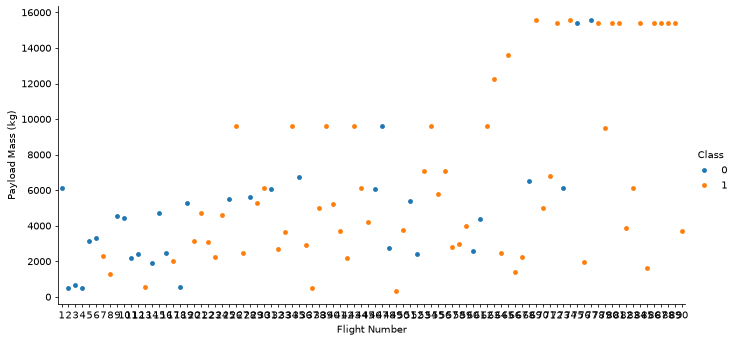

In [2]:
sns.catplot(y='PayloadMass', x='FlightNumber', hue='Class', data=df, aspect=2)
plt.xlabel('Flight Number'); plt.ylabel('Payload Mass (kg)'); plt.show()

### Flight Number vs. Launch Site

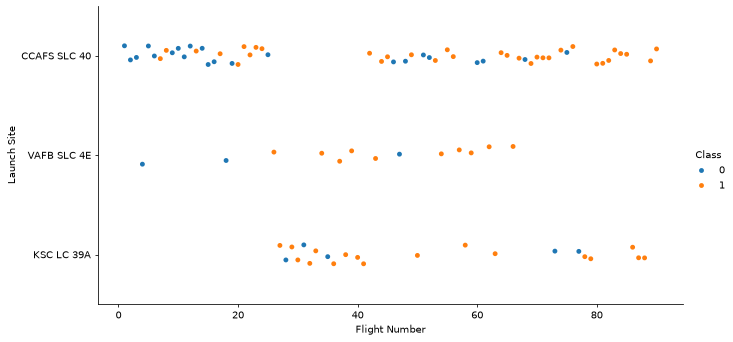

In [3]:
sns.catplot(x='FlightNumber', y='LaunchSite', hue='Class', data=df, aspect=2)
plt.xlabel('Flight Number'); plt.ylabel('Launch Site'); plt.show()

### Payload Mass vs. Launch Site

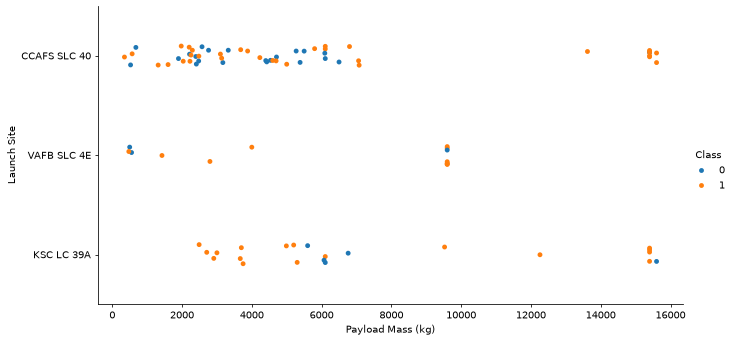

In [4]:
sns.catplot(x='PayloadMass', y='LaunchSite', hue='Class', data=df, aspect=2)
plt.xlabel('Payload Mass (kg)'); plt.ylabel('Launch Site'); plt.show()

### Success rate of each orbit type

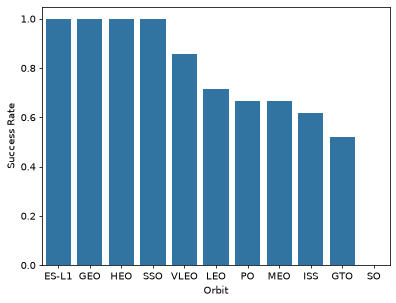

In [5]:
orbit = df.groupby('Orbit')['Class'].mean().sort_values(ascending=False)
sns.barplot(x=orbit.index, y=orbit.values)
plt.xlabel('Orbit'); plt.ylabel('Success Rate'); plt.show()

### Flight Number vs. Orbit type

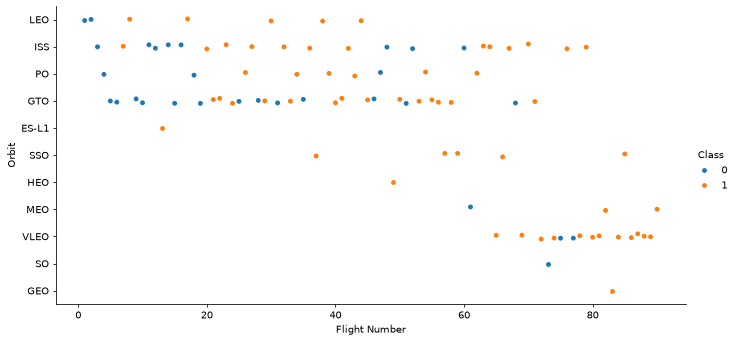

In [6]:
sns.catplot(x='FlightNumber', y='Orbit', hue='Class', data=df, aspect=2)
plt.xlabel('Flight Number'); plt.ylabel('Orbit'); plt.show()

### Payload Mass vs. Orbit type

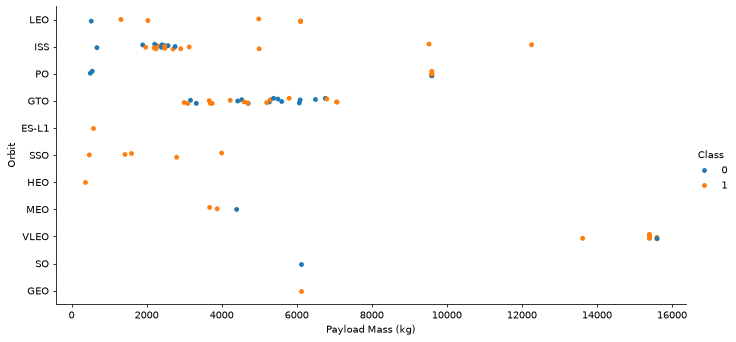

In [7]:
sns.catplot(x='PayloadMass', y='Orbit', hue='Class', data=df, aspect=2)
plt.xlabel('Payload Mass (kg)'); plt.ylabel('Orbit'); plt.show()

### Yearly average success trend

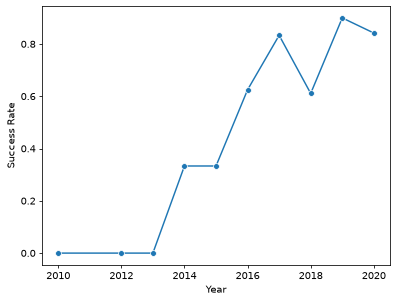

In [8]:
df['Year'] = pd.to_datetime(df['Date']).dt.year
yearly = df.groupby('Year')['Class'].mean().reset_index()
sns.lineplot(data=yearly, x='Year', y='Class', marker='o')
plt.xlabel('Year'); plt.ylabel('Success Rate'); plt.show()

### Feature engineering: one-hot encode categorical columns

In [9]:
features = df[['FlightNumber','PayloadMass','Orbit','LaunchSite','Flights','GridFins','Reused','Legs','LandingPad','Block','ReusedCount','Serial']]
features_one_hot = pd.get_dummies(features, columns=['Orbit','LaunchSite','LandingPad','Serial','GridFins','Reused','Legs'])
features_one_hot = features_one_hot.astype('float64')
features_one_hot.to_csv('dataset_part_3.csv', index=False)
print('shape:', features_one_hot.shape)

shape: (90, 83)
